In [4]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
df = pd.read_csv(r"C:\Users\Hp\Downloads\archive (8)\loan_data.csv")

In [5]:
df.head(5)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381 entries, 0 to 380
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            381 non-null    object 
 1   Gender             376 non-null    object 
 2   Married            381 non-null    object 
 3   Dependents         373 non-null    object 
 4   Education          381 non-null    object 
 5   Self_Employed      360 non-null    object 
 6   ApplicantIncome    381 non-null    int64  
 7   CoapplicantIncome  381 non-null    float64
 8   LoanAmount         381 non-null    float64
 9   Loan_Amount_Term   370 non-null    float64
 10  Credit_History     351 non-null    float64
 11  Property_Area      381 non-null    object 
 12  Loan_Status        381 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 38.8+ KB


In [7]:
df.shape

(381, 13)

In [8]:
df.isnull().sum()

Loan_ID               0
Gender                5
Married               0
Dependents            8
Education             0
Self_Employed        21
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     11
Credit_History       30
Property_Area         0
Loan_Status           0
dtype: int64

In [9]:
df.select_dtypes(include="object").isnull().sum()

Loan_ID           0
Gender            5
Married           0
Dependents        8
Education         0
Self_Employed    21
Property_Area     0
Loan_Status       0
dtype: int64

In [10]:
for i in df.select_dtypes(include="object").columns:
    df[i].fillna(df[i].mode()[0],inplace=True)

In [11]:
df['Credit_History'].fillna(df['Credit_History'].mode()[0],inplace=True)

In [12]:
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0],inplace=True)

In [13]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [83]:
df.select_dtypes(include="float64").columns


Index(['CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term',
       'Credit_History'],
      dtype='object')

In [84]:
from sklearn.impute import SimpleImputer


In [85]:
si=SimpleImputer(strategy="mean")
ar=si.fit_transform(df[['CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term',
       'Credit_History']])

In [86]:
df=pd.DataFrame(ar,columns=df.select_dtypes(include="float64").columns)

In [87]:
df.head()

,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,1508.0,128.0,360.0,1.0
1,0.0,66.0,360.0,1.0
2,2358.0,120.0,360.0,1.0
3,0.0,141.0,360.0,1.0
4,1516.0,95.0,360.0,1.0


In [88]:
df.isnull().sum()

CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
dtype: int64

In [14]:
en_data=df[["Gender","Married"]]

In [15]:
en_data

,Gender,Married
0,Male,Yes
1,Male,Yes
2,Male,Yes
3,Male,No
4,Male,Yes
...,...,...
376,Male,Yes
377,Male,Yes
378,Female,No
379,Male,Yes


In [16]:
pd.get_dummies(en_data)

,Gender_Female,Gender_Male,Married_No,Married_Yes
0,False,True,False,True
1,False,True,False,True
2,False,True,False,True
3,False,True,True,False
4,False,True,False,True
...,...,...,...,...
376,False,True,False,True
377,False,True,False,True
378,True,False,True,False
379,False,True,False,True


In [17]:
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder(drop="first")

In [18]:
ar=ohe.fit_transform(en_data).toarray()

In [19]:
ar

array([[1., 1.],
       [1., 1.],
       [1., 1.],
       [1., 0.],
       [1., 1.],
       [1., 1.],
       [1., 1.],
       [1., 0.],
       [1., 1.],
       [1., 0.],
       [1., 0.],
       [0., 0.],
       [1., 1.],
       [1., 1.],
       [1., 1.],
       [1., 1.],
       [1., 1.],
       [1., 1.],
       [1., 1.],
       [1., 0.],
       [0., 0.],
       [1., 0.],
       [1., 0.],
       [1., 1.],
       [1., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 1.],
       [1., 1.],
       [1., 1.],
       [0., 0.],
       [1., 1.],
       [1., 1.],
       [0., 1.],
       [0., 0.],
       [0., 1.],
       [0., 0.],
       [0., 0.],
       [1., 1.],
       [1., 1.],
       [1., 1.],
       [1., 1.],
       [1., 1.],
       [1., 1.],
       [1., 1.],
       [0., 0.],
       [1., 0.],
       [1., 1.],
       [0., 0.],
       [1., 1.],
       [1., 0.],
       [1., 1.],
       [1., 0.],
       [1., 1.],
       [1., 1.],
       [0., 0.],
       [1., 1.

In [20]:
ohe1=pd.DataFrame(ar,columns=["Gender_Male","Married_Yes"])

In [21]:
ohe1.head()

,Gender_Male,Married_Yes
0,1.0,1.0
1,1.0,1.0
2,1.0,1.0
3,1.0,0.0
4,1.0,1.0


In [22]:
new_df = pd.concat([df, ohe1], axis=1).drop(columns=['Gender','Married'])

In [23]:
new_df.head()

,Loan_ID,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Gender_Male,Married_Yes
0,LP001003,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,1.0,1.0
1,LP001005,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,1.0,1.0
2,LP001006,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,1.0,1.0
3,LP001008,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,1.0,0.0
4,LP001013,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y,1.0,1.0


In [24]:
from sklearn.preprocessing import LabelEncoder

In [25]:
le=LabelEncoder()

In [26]:
new_df["Property_Area"].unique()

array(['Rural', 'Urban', 'Semiurban'], dtype=object)

In [27]:
new_df["Property_Area"]=le.fit_transform(new_df["Property_Area"])

In [28]:
new_df["Loan_Status"]=le.fit_transform(new_df["Loan_Status"])

In [29]:
new_df.head()

,Loan_ID,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Gender_Male,Married_Yes
0,LP001003,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,0,0,1.0,1.0
1,LP001005,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,2,1,1.0,1.0
2,LP001006,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,2,1,1.0,1.0
3,LP001008,0,Graduate,No,6000,0.0,141.0,360.0,1.0,2,1,1.0,0.0
4,LP001013,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,2,1,1.0,1.0


In [30]:
new_df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Gender_Male,Married_Yes
count,381.000000,381.000000,381.000000,381.000000,381.000000,381.000000,381.000000,381.000000,381.000000
mean,3579.845144,1277.275381,104.986877,341.417323,0.850394,1.052493,0.711286,0.776903,0.598425
std,1419.813818,2340.818114,28.358464,67.625957,0.357154,0.779592,0.453761,0.416870,0.490861
min,150.000000,0.000000,9.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2600.000000,0.000000,90.000000,360.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,3333.000000,983.000000,110.000000,360.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,4288.000000,2016.000000,127.000000,360.000000,1.000000,2.000000,1.000000,1.000000,1.000000
max,9703.000000,33837.000000,150.000000,480.000000,1.000000,2.000000,1.000000,1.000000,1.000000


In [31]:
new_df['Self_Employed'] = new_df['Self_Employed'].map({'No': 0, 'Yes': 1})

In [32]:
new_df['Education'] = new_df['Education'].map({'Graduate': 1, 'Not Graduate': 0})

In [33]:
new_df.head()

,Loan_ID,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Gender_Male,Married_Yes
0,LP001003,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0,1.0,1.0
1,LP001005,0,1,1,3000,0.0,66.0,360.0,1.0,2,1,1.0,1.0
2,LP001006,0,0,0,2583,2358.0,120.0,360.0,1.0,2,1,1.0,1.0
3,LP001008,0,1,0,6000,0.0,141.0,360.0,1.0,2,1,1.0,0.0
4,LP001013,0,0,0,2333,1516.0,95.0,360.0,1.0,2,1,1.0,1.0


In [34]:
new_df['Credit_History'].unique()

array([1., 0.])

In [35]:
new_df['Dependents'] = new_df['Dependents'].replace('3+','3').astype(float)

In [36]:
new_df['Dependents'].unique()

array([1., 0., 2., 3.])

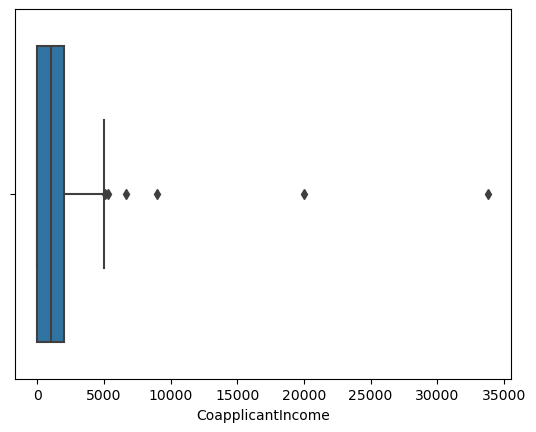

In [37]:
sns.boxplot(x="CoapplicantIncome",data=new_df)
plt.show()

C:\Users\Hp\AppData\Local\Temp\ipykernel_19864\71723079.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["CoapplicantIncome"])
C:\Users\Hp\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


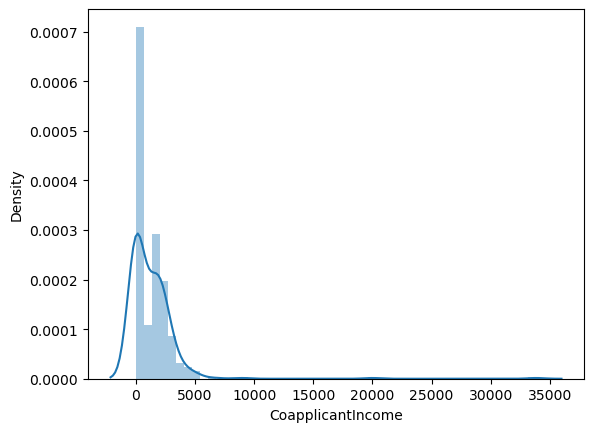

In [38]:
sns.distplot(df["CoapplicantIncome"])
plt.show()

In [39]:
q1=df["CoapplicantIncome"].quantile(0.25)
q3=df["CoapplicantIncome"].quantile(0.75)

In [40]:
IQR=q3-q1

In [41]:
min_range=q1-(1.5*IQR)
max_range=q3+(1.5*IQR)

In [42]:
neww_df=new_df[new_df["CoapplicantIncome"]<=max_range]

In [43]:
neww_df.describe()

,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Gender_Male,Married_Yes
count,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000
mean,0.674667,0.728000,0.093333,3598.272000,1084.783787,105.053333,341.600000,0.850667,1.056000,0.717333,0.776000,0.602667
std,0.992363,0.445584,0.291288,1420.366954,1200.169089,28.349657,67.618939,0.356893,0.780484,0.450897,0.417479,0.490000
min,0.000000,0.000000,0.000000,150.000000,0.000000,9.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,2600.000000,0.000000,90.000000,360.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,0.000000,1.000000,0.000000,3340.000000,830.000000,110.000000,360.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,1.000000,1.000000,0.000000,4300.500000,1985.000000,127.000000,360.000000,1.000000,2.000000,1.000000,1.000000,1.000000
max,3.000000,1.000000,1.000000,9703.000000,5000.000000,150.000000,480.000000,1.000000,2.000000,1.000000,1.000000,1.000000


In [44]:
neww_df.shape

(375, 13)

In [45]:
neww_df.drop_duplicates(inplace=True)

C:\Users\Hp\AppData\Local\Temp\ipykernel_19864\450580949.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neww_df.drop_duplicates(inplace=True)


In [46]:
neww_df.head()

,Loan_ID,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Gender_Male,Married_Yes
0,LP001003,1.0,1,0,4583,1508.0,128.0,360.0,1.0,0,0,1.0,1.0
1,LP001005,0.0,1,1,3000,0.0,66.0,360.0,1.0,2,1,1.0,1.0
2,LP001006,0.0,0,0,2583,2358.0,120.0,360.0,1.0,2,1,1.0,1.0
3,LP001008,0.0,1,0,6000,0.0,141.0,360.0,1.0,2,1,1.0,0.0
4,LP001013,0.0,0,0,2333,1516.0,95.0,360.0,1.0,2,1,1.0,1.0


AttributeError: 'numpy.int32' object has no attribute 'startswith'

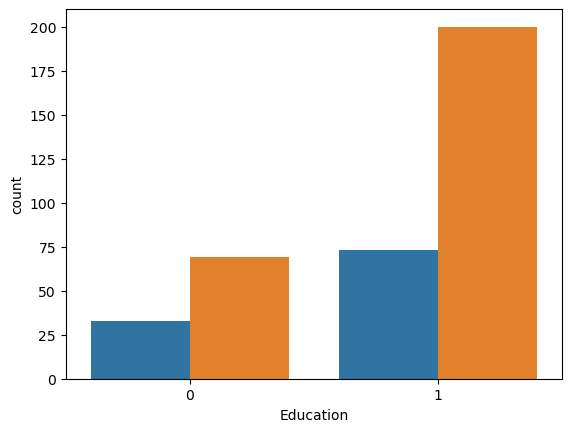

In [47]:
sns.countplot(x=neww_df['Education'],hue=neww_df['Loan_Status'])

In [50]:
neww_df=neww_df.drop("Loan_ID",axis=1)

In [51]:
neww_df=neww_df.drop("Education",axis=1)

KeyError: "['Education'] not found in axis"

In [ ]:
neww_df.head()

In [52]:
X=neww_df.iloc[:,:-1]
Y=neww_df["Loan_Status"]

In [53]:
print(X)

     Dependents  Self_Employed  ApplicantIncome  CoapplicantIncome  \
0           1.0              0             4583             1508.0   
1           0.0              1             3000                0.0   
2           0.0              0             2583             2358.0   
3           0.0              0             6000                0.0   
4           0.0              0             2333             1516.0   
..          ...            ...              ...                ...   
376         3.0              0             5703                0.0   
377         0.0              0             3232             1950.0   
378         0.0              0             2900                0.0   
379         3.0              0             4106                0.0   
380         0.0              1             4583                0.0   

     LoanAmount  Loan_Amount_Term  Credit_History  Property_Area  Loan_Status  \
0         128.0             360.0             1.0              0            0 

In [54]:
print(Y)


0      0
1      1
2      1
3      1
4      1
      ..
376    1
377    1
378    1
379    1
380    0
Name: Loan_Status, Length: 375, dtype: int32


In [55]:
Y.shape

(375,)

In [56]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [57]:
from sklearn.model_selection import train_test_split

In [58]:
X_train,X_test,Y_train,Y_test= train_test_split(X,Y,test_size=0.2,random_state=2)

In [59]:
print(X_train)

     Dependents  Self_Employed  ApplicantIncome  CoapplicantIncome  \
228         0.0              1             6822                0.0   
180         0.0              0             3704             2000.0   
332         0.0              0             3775                0.0   
111         0.0              0             4600                0.0   
109         0.0              0             2333             1451.0   
..          ...            ...              ...                ...   
302         3.0              0             4691                0.0   
22          1.0              1             4692                0.0   
72          0.0              0             7333                0.0   
15          0.0              0             2600             1911.0   
170         0.0              0             2620             2223.0   

     LoanAmount  Loan_Amount_Term  Credit_History  Property_Area  Loan_Status  \
228       141.0             360.0             1.0              0            1 

In [60]:
print(X_test)

     Dependents  Self_Employed  ApplicantIncome  CoapplicantIncome  \
327         0.0              0             3074             1800.0   
222         0.0              0             3813                0.0   
70          2.0              0             4288             3263.0   
121         1.0              0             3500             1083.0   
32          0.0              0             3410                0.0   
..          ...            ...              ...                ...   
171         2.0              0             3900                0.0   
3           0.0              0             6000                0.0   
292         0.0              0             4301                0.0   
216         3.0              0             3173                0.0   
361         0.0              0             3087             2210.0   

     LoanAmount  Loan_Amount_Term  Credit_History  Property_Area  Loan_Status  \
327       123.0             360.0             0.0              1            0 

In [61]:
print(Y_train)

228    1
180    1
332    1
111    1
109    0
      ..
302    1
22     0
72     0
15     0
170    1
Name: Loan_Status, Length: 300, dtype: int32


In [62]:
print(Y_test)

327    0
222    1
70     1
121    1
32     1
      ..
171    1
3      1
292    1
216    1
361    0
Name: Loan_Status, Length: 75, dtype: int32


In [63]:
from sklearn.linear_model import LogisticRegression
log=LogisticRegression()
log.fit(X_train,Y_train)

C:\Users\Hp\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [64]:
pred1=log.predict(X_test)

In [65]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score

In [66]:
(accuracy_score(Y_test,pred1))*100

100.0

In [67]:
(precision_score(Y_test,pred1))*100

100.0

In [68]:
(recall_score(Y_test,pred1))*100

100.0

In [69]:
(f1_score(Y_test,pred1))*100

100.0

In [70]:
from sklearn.metrics import classification_report,confusion_matrix

In [71]:
confusion_matrix(Y_test,pred1)

array([[18,  0],
       [ 0, 57]], dtype=int64)

In [72]:
print(classification_report(Y_test,pred1))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        57

    accuracy                           1.00        75
   macro avg       1.00      1.00      1.00        75
weighted avg       1.00      1.00      1.00        75



In [73]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()
knn.fit(X_train,Y_train)

KNeighborsClassifier()

In [74]:
pred2=knn.predict(X_test)

In [75]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report

In [76]:
(accuracy_score(Y_test,pred1))*100

100.0

In [77]:
(precision_score(Y_test,pred1))*100

100.0

In [78]:
(recall_score(Y_test,pred1))*100

100.0

In [79]:
(f1_score(Y_test,pred1))*100

100.0

In [80]:
from sklearn.metrics import classification_report,confusion_matrix

In [81]:
confusion_matrix(Y_test,pred1)

array([[18,  0],
       [ 0, 57]], dtype=int64)

In [82]:
print(classification_report(Y_test,pred2))

              precision    recall  f1-score   support

           0       0.20      0.11      0.14        18
           1       0.75      0.86      0.80        57

    accuracy                           0.68        75
   macro avg       0.48      0.49      0.47        75
weighted avg       0.62      0.68      0.64        75



In [83]:
from sklearn.tree import DecisionTreeClassifier
de=DecisionTreeClassifier()
de.fit(X_train,Y_train)

DecisionTreeClassifier()

In [84]:
pred3=de.predict(X_test)

In [85]:
(accuracy_score(Y_test,pred3))*100
(precision_score(Y_test,pred3))*100
(recall_score(Y_test,pred3))*100
(f1_score(Y_test,pred3))*100


100.0

In [86]:
confusion_matrix(Y_test,pred3)

array([[18,  0],
       [ 0, 57]], dtype=int64)

In [87]:
print(classification_report(Y_test,pred3))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        57

    accuracy                           1.00        75
   macro avg       1.00      1.00      1.00        75
weighted avg       1.00      1.00      1.00        75



In [88]:
from sklearn.ensemble import GradientBoostingClassifier
gr = GradientBoostingClassifier()
gr.fit(X_train,Y_train)

GradientBoostingClassifier()

In [89]:
pred4 = gr.predict(X_test)

In [90]:
(accuracy_score(Y_test,pred3))*100
(precision_score(Y_test,pred3))*100
(recall_score(Y_test,pred3))*100
(f1_score(Y_test,pred3))*100


100.0

In [91]:
confusion_matrix(Y_test,pred4)

array([[18,  0],
       [ 0, 57]], dtype=int64)

In [92]:
print(classification_report(Y_test,pred4))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        57

    accuracy                           1.00        75
   macro avg       1.00      1.00      1.00        75
weighted avg       1.00      1.00      1.00        75



In [93]:
print((Y_test == pred4).sum(), "out of", len(Y_test))

75 out of 75


In [94]:
import pandas as pd
final_df=pd.DataFrame({'Models':['LR','KNN','DT','GBC'],'ACC':[accuracy_score(Y_test,pred1)*100,accuracy_score(Y_test,pred2)*100,accuracy_score(Y_test,pred3)*100,accuracy_score(Y_test,pred4)*100]})

In [95]:
final_df

,Models,ACC
0,LR,100.0
1,KNN,68.0
2,DT,100.0
3,GBC,100.0


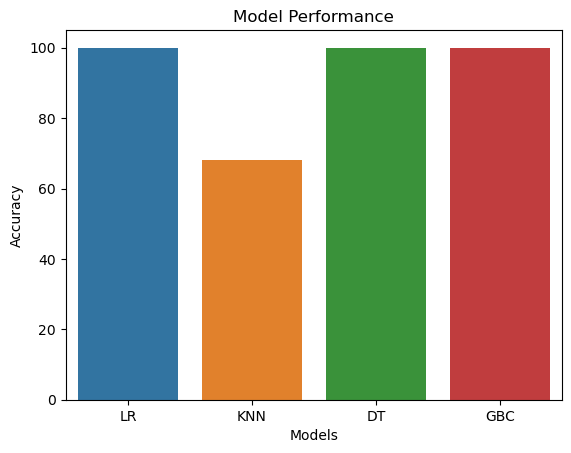

In [96]:
sns.barplot(x='Models', y='ACC',data=final_df)
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model Performance')
plt.show()

In [97]:
final_df=pd.DataFrame({'Models' : ['LR','KNN','DT','GBC'],'PRE':[precision_score(Y_test,pred1)*100,precision_score(Y_test,pred2)*100,precision_score(Y_test,pred3)*100,precision_score(Y_test,pred4)*100]})

In [98]:
final_df

,Models,PRE
0,LR,100.000000
1,KNN,75.384615
2,DT,100.000000
3,GBC,100.000000


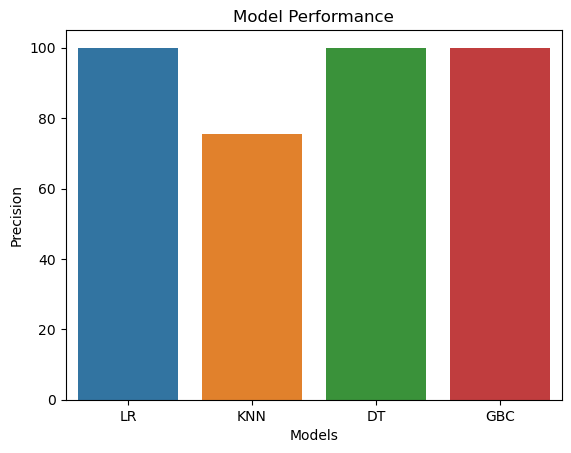

In [99]:
sns.barplot(x='Models', y='PRE',data=final_df)
plt.xlabel('Models')
plt.ylabel('Precision')
plt.title('Model Performance')
plt.show()

In [103]:
final_df=pd.DataFrame({'Models' : ['LR','KNN','DT','GBC'],'F1':[f1_score(Y_test,pred1)*100,f1_score(Y_test,pred2)*100,f1_score(Y_test,pred3)*100,f1_score(Y_test,pred4)*100]})

In [104]:
final_df

,Models,F1
0,LR,100.000000
1,KNN,80.327869
2,DT,100.000000
3,GBC,100.000000


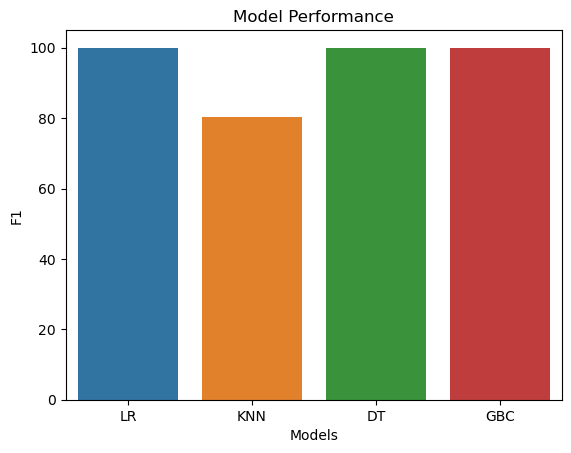

In [105]:
sns.barplot(x='Models', y='F1',data=final_df)
plt.xlabel('Models')
plt.ylabel('F1')
plt.title('Model Performance')
plt.show()

In [107]:
import joblib
joblib.dump(gr,'churn_prediction_model')

['churn_prediction_model']

In [109]:
model=joblib.load('churn_prediction_model')

In [111]:
model.predict([[419.0, 2.0, 0.0, 0.0, 1.0, 1.0, 101.348, 1,0,1.0]])

C:\Users\Hp\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


array([0])